# National Seasonal Pattern Analysis

This notebook ranks stores by how closely they align with the national seasonal pattern. The output includes both a table and an inline bar chart.

In [1]:
import pandas as pd

store_data = [
    ("Zava Retail Seattle", 30, 3.0),
    ("Zava Retail Bellevue", 25, 2.6),
    ("Zava Retail Tacoma", 20, 2.4),
    ("Zava Retail Spokane", 8, 2.0),
    ("Zava Retail Everett", 7, 1.8),
    ("Zava Retail Redmond", 6, 1.6),
    ("Zava Retail Kirkland", 4, 1.4),
    ("Zava Retail Online", 30, 3.0),
]

rows = []
for store, weight, freq in store_data:
    alignment = weight * freq
    rows.append({
        'Store': store,
        'Weight': weight,
        'Frequency': freq,
        'Alignment Index': alignment,
    })

summary = pd.DataFrame(rows).sort_values('Alignment Index', ascending=False).reset_index(drop=True)
summary

,Store,Weight,Frequency,Alignment Index
0,Zava Retail Seattle,30,3.0,90.0
1,Zava Retail Online,30,3.0,90.0
2,Zava Retail Bellevue,25,2.6,65.0
3,Zava Retail Tacoma,20,2.4,48.0
4,Zava Retail Spokane,8,2.0,16.0
5,Zava Retail Everett,7,1.8,12.6
6,Zava Retail Redmond,6,1.6,9.6
7,Zava Retail Kirkland,4,1.4,5.6


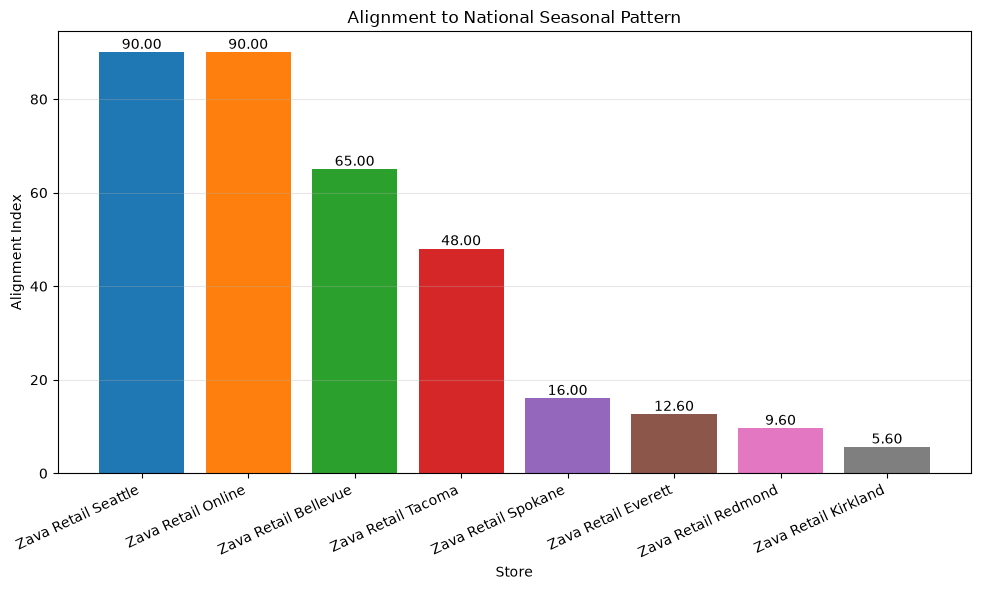

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

top = summary
plt.figure(figsize=(10, 6))
bars = plt.bar(top['Store'], top['Alignment Index'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f'])
plt.title('Alignment to National Seasonal Pattern')
plt.xlabel('Store')
plt.ylabel('Alignment Index')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, top['Alignment Index']):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.05, f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()